# Regularization Methods Demonstration In Python

## Objective
To develop a model/method for identifying customers who are likely to exit

## Background:
Bank customer churn, also known as customer attrition, refers to the phenomenon where customers stop doing business with a bank or switch to another bank. Churn is a critical metric for banks as it directly impacts their customer base and revenue. The dataset represents bank customer information for churn analysis. Each row in the dataset corresponds to a specific customer and contains several features or attributes that describe them.

While we have worked with Binary Logistic Regression, Naive Bayes, SVM and tree based methods in earlier case study, we will be using neural network in this one.

## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from skorch import NeuralNetClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [2]:
# Set seeds for reproducibility (mirrors random_state=42 / random_state=1)
torch.manual_seed(1)
np.random.seed(42)

### Import Data

In [3]:
data = pd.read_csv('Bank Churn.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Description

| Field           | Description                                            |
| --------------- | ------------------------------------------------------ |
| CustomerId      | Customer identifiers                                   |
| Surname         | Surname of Customer                                    |
| CreditScore     | Creditworthiness score of customers                    |
| Geography       | Country name                                           |
| Gender          | Gender of customer                                     |
| Age             | Age of customer                                        |
| Tenure          | Duration of customer engagement or membership          |
| Balance         | Amount of funds held in customer accounts              |
| NumOfProducts   | Number of products or services owned by customers      |
| HasCrCard       | Whether customers possess a credit card or not         |
| IsActiveMember  | Whether customers are active member of loyalty program |
| EstimatedSalary | The approximate salary of customers                    |
| Exited          | Whether customers have churned or exited the service   |


### Splitting Data into Train and Test data sets


In [4]:
X = data.drop(['RowNumber','CustomerId','Exited','Surname'],axis = 1)
y = data['Exited']


# Split data into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Create Dummies and Standardize numeric variables for Train and Test

In [5]:
#Standardize numeric variables

numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()

# Fit ONLY on training data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Use same scaler on test data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


#Define categorical columns
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

# Apply get_dummies on TRAIN
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

#Align test columns with train (VERY IMPORTANT)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


# Convert everything to numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


### Convert to PyTorch tensors
At this point X_train / X_test are pandas DataFrames and y_train / y_test are pandas Series — convenient for preprocessing but incompatible with PyTorch. All nn.Module layers, loss functions, and the autograd engine require torch.Tensor inputs. 

The conversion below is a one-time handoff: pandas handles cleaning/scaling/encoding, then PyTorch takes over for the entire forward pass, loss computation, and backpropagation

In [6]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

## Define & Train the Neural Network

In [7]:
input_dim = X_train_t.shape[1]   # number of input features

### 1. Model with 16 neurons

In [8]:
model_16 = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 16),                         
        nn.ReLU(),                
        nn.Linear(16, 1)         
    ),

    max_epochs=300,              
    optimizer=optim.Adam,        
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,              
    verbose=0                   
)

model_16.fit(X_train_t, y_train_t)


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  ),
)

###  2. Using L2 Regularization
L2 Regularization (weight_decay): Penalizes large weights to reduce overfitting and improve generalization.

In [9]:
model_16_l2 = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    ),
    max_epochs=300,
    optimizer=optim.Adam,
    optimizer__weight_decay=0.01,   # L2 Regularization = 0.01
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,
    verbose=0
)

model_16_l2.fit(X_train_t, y_train_t)

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  ),
)

### 3.	Using Dropout method

Dropout: Randomly deactivates neurons during training to prevent overfitting.

In [10]:
model_16_do = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Dropout(p=0.5),   # Dropout added
        nn.Linear(16, 1)
    ),
    max_epochs=300,
    optimizer=optim.Adam,
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,
    verbose=0
)

model_16_do.fit(X_train_t, y_train_t)

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  ),
)

### 4.	Using Batch Normalization

Batch Normalization: Normalizes layer inputs to stabilize and speed up training.

In [11]:
model_16_bn = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.BatchNorm1d(16),   # Batch Normalization added
        nn.ReLU(),
        nn.Linear(16, 1)
    ),
    max_epochs=300,
    optimizer=optim.Adam,
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,
    verbose=0
)

model_16_bn.fit(X_train_t, y_train_t)

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=1, bias=True)
  ),
)

### 5.	Compare three models using ROC curves and AUC scores.

In [12]:
def evaluate_model(model, X_test_t, y_test_t):
    
    # Get logits
    y_logits = model.predict_proba(X_test_t)[:, 1]
    
    # Convert to class (0/1)
    y_pred = (y_logits > 0.5).astype(int)
    
    print("Classification Report:\n")
    print(classification_report(y_test_t, y_pred))
    
    auc = roc_auc_score(y_test_t, y_logits)
    print("AUC Score:", auc)
    
    return auc

In [13]:
print("Model with 16 neurons")
evaluate_model(model_16, X_test_t, y_test_t)

print("\nL2 Regularization")
evaluate_model(model_16_l2, X_test_t, y_test_t)

print("\nDrpoout")
evaluate_model(model_16_do, X_test_t, y_test_t)

print("\nBatch Normalization")
evaluate_model(model_16_bn, X_test_t, y_test_t)

Model with 16 neurons
Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91      1593
         1.0       0.72      0.51      0.60       407

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000

AUC Score: 0.8567257550308398

L2 Regularization
Classification Report:

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.92      1593
         1.0       0.80      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000

AUC Score: 0.8513768005293428

Drpoout
Classification Report:

              precision    recall  f1-score   support

         0.0       0.83      0.99      0.90      1593
         1.0       0.85      0.19      0.31       407



0.8638777452336776

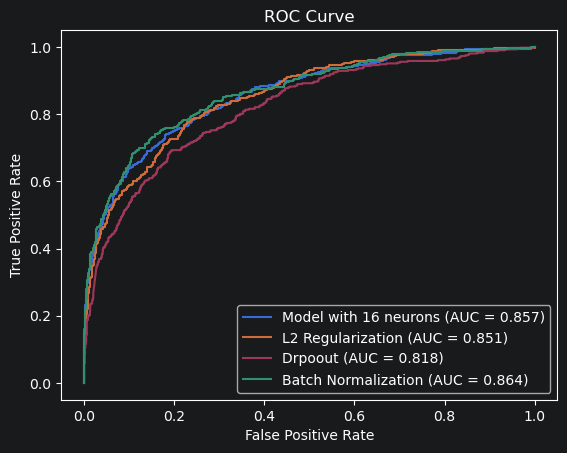

In [14]:
def plot_roc(model, X_test_t, y_test_t, title):
    # Get predicted probabilities
    y_probs = model.predict_proba(X_test_t)[:, 1]
    
    # ROC values
    fpr, tpr, _ = roc_curve(y_test_t, y_probs)
    
    # AUC calculation
    auc_score = roc_auc_score(y_test_t, y_probs)
    
    # Plot with AUC in legend
    plt.plot(fpr, tpr, label=f"{title} (AUC = {auc_score:.3f})")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

# Plot multiple models
plot_roc(model_16, X_test_t, y_test_t, "Model with 16 neurons")
plot_roc(model_16_l2, X_test_t, y_test_t, "L2 Regularization")
plot_roc(model_16_do, X_test_t, y_test_t, "Drpoout")
plot_roc(model_16_bn, X_test_t, y_test_t, "Batch Normalization")


plt.show()

### Conclusion :

There is no significant difference in performance across the models, with the model using **16 neurons and batch normalization performing slightly better (AUC = ~0.86)** compared to the others.
